### Contains: 
### 1. Exploratory Data Analysis
    1.1 Variance Inflation Factor (VIF)
### 2. Anomaly Detection
    2.1. Preprocessing
    2.2 Isolation Forest on Carrier Samples
    2.3. Set threshold in Anomaly score
### 3. Classifier modeling
    3.1. Pre-processing
    3.2. Nested Cross-validation
    3.3. Prediction of Anomaly Carriers (Holdout set) using best classifier based on PRAUC score
    3.4. Predicted probability of HAM among Anomaly Carrier samples
### 4. Statistical Analysis
    4.1. Pre-processing
    4.2. Kruskal-Wallis test
### 5. Appendix
    5.1. Correlation between Feature values
    5.2. Contour plot of Anomaly score distribution among Carriers
    5.3. Anomaly score vs Feature value of Anomaly carriers
    5.4. Correlation between Feature values & Predicted probability of HAM among Anomaly carriers
### 6. Required packages

# 1. Exploratory Data Analysis

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline
import itertools
import warnings
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', RuntimeWarning)
warnings.simplefilter('ignore', UserWarning)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [4]:
# load the data 
data = pd.read_csv('all_data_copy.csv', index_col=0)
data = data.replace('Carrier_to_ATL','ATL')
data = data.replace('Carrier_to_HAM','Carrier')

In [5]:
data.head()

,PVL,Tax,Env,Gag p15,Gag p19,Gag p24,type
indivID,,,,,,,
indiv0001,4.600,520.000,272.000,260.000,99954.000,13909.000,Carrier
indiv0002,0.200,1628.000,126.000,172.000,27483.000,6809.000,Carrier
indiv0003,0.100,2238.000,290.000,156.000,151627.000,761360.000,Carrier
indiv0004,1.200,4787.000,726.000,422.000,42721.000,603196.000,Carrier
indiv0005,7.500,912.000,2292.000,278.000,948739.000,792544.000,Carrier


## 1.2. Variance Inflation Factor (VIF) Analysis

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [7]:
df = data.copy()
df.columns

Index(['PVL', 'Tax', 'Env', 'Gag p15', 'Gag p19', 'Gag p24', 'type'], dtype='object')

In [8]:
# variables
var_1 = df[['PVL', 'Tax', 'Env', 'Gag p15', 'Gag p19', 'Gag p24']]

In [9]:
# Calculate VIF
vif_data_1 = pd.DataFrame()
vif_data_1['Features'] = var_1.columns
vif_data_1['VIF score'] = [variance_inflation_factor(var_1.values, i) for i in range(var_1.shape[1])]

In [10]:
vif_data_1

,Features,VIF score
0,PVL,1.145
1,Tax,1.634
2,Env,3.042
3,Gag p15,1.314
4,Gag p19,7.481
5,Gag p24,6.141


In [11]:
df.drop('Gag p19', axis=1, inplace=True)

In [12]:
var_2 = df[['PVL', 'Tax', 'Env', 'Gag p15', 'Gag p24']]

In [13]:
# Calculate VIF
vif_data_2 = pd.DataFrame()
vif_data_2['Features'] = var_2.columns
vif_data_2['VIF score'] = [variance_inflation_factor(var_2.values, i) for i in range(var_2.shape[1])]

In [14]:
vif_data_2

,Features,VIF score
0,PVL,1.110
1,Tax,1.631
2,Env,2.462
3,Gag p15,1.293
4,Gag p24,2.794


# 2. Anomaly Detection

## 2.1. Preprocessing

In [15]:
data.head()

,PVL,Tax,Env,Gag p15,Gag p19,Gag p24,type
indivID,,,,,,,
indiv0001,4.600,520.000,272.000,260.000,99954.000,13909.000,Carrier
indiv0002,0.200,1628.000,126.000,172.000,27483.000,6809.000,Carrier
indiv0003,0.100,2238.000,290.000,156.000,151627.000,761360.000,Carrier
indiv0004,1.200,4787.000,726.000,422.000,42721.000,603196.000,Carrier
indiv0005,7.500,912.000,2292.000,278.000,948739.000,792544.000,Carrier


In [16]:
data['target'] = data['type'].map({'Carrier': 0, 'ATL': 1, 'HAM': 2})

In [17]:
datad = data.copy()

In [18]:
datad.drop('Gag p19', axis=1, inplace=True)

In [19]:
carrier_data = datad[datad['target']==0]

In [20]:
carrier_data.columns

Index(['PVL', 'Tax', 'Env', 'Gag p15', 'Gag p24', 'type', 'target'], dtype='object')

In [21]:
X_carrier = carrier_data.drop(['type','target'], axis=1)

In [22]:
X_carrier.shape

(264, 5)

In [23]:
X_carrier.columns

Index(['PVL', 'Tax', 'Env', 'Gag p15', 'Gag p24'], dtype='object')

In [24]:
import sklearn
sklearn.__version__

'1.5.2'

## 2.2. Isolation Forest on Carrier samples

In [25]:
from sklearn.ensemble import IsolationForest

In [26]:
# Isolation Forest model 
iforest = IsolationForest(contamination= 'auto', max_samples = 'auto', n_estimators= 300, random_state= 42)

In [27]:
iforest.fit(X_carrier)

IsolationForest(n_estimators=300, random_state=42)

In [28]:
# anomaly score
anomaly_scores_carrier = iforest.decision_function(X_carrier)

In [29]:
min_anomaly= anomaly_scores_carrier.min()
max_anomaly= anomaly_scores_carrier.max()

In [30]:
print(min_anomaly)
print(max_anomaly)

-0.2273102462372898
0.15105609123304709


## 2.3. Set threshold in Anomaly score

In [31]:
# set threshold
threshold = -0.05

# indices of actual anomalies
anomaly_indices_carrier = [index for index, score in enumerate(anomaly_scores_carrier) if score <= threshold]

# Get the actual anomalies from dataset
actual_anomalies_carrier = X_carrier.iloc[anomaly_indices_carrier]

In [32]:
len(actual_anomalies_carrier)

17

In [33]:
anomalous_data_carrier = actual_anomalies_carrier.copy()

# get the index rows 
anomalous_indices_carrier = anomalous_data_carrier.index

# new df excluding the anomaly samples
clean_df = datad.drop(anomalous_indices_carrier)

In [34]:
actual_anomalies_carrier.loc[:, 'Anomaly_Score'] = anomaly_scores_carrier[anomaly_indices_carrier]

/var/folders/_4/p4p8llrs7s97qrcpyfmwrnx00000gn/T/ipykernel_52006/3589506611.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_anomalies_carrier.loc[:, 'Anomaly_Score'] = anomaly_scores_carrier[anomaly_indices_carrier]


In [35]:
anomaly_scores_carrier_plot = np.sort(anomaly_scores_carrier)

In [36]:
actual_anomalies_carrier

,PVL,Tax,Env,Gag p15,Gag p24,Anomaly_Score
indivID,,,,,,
indiv0027,35.100,46360.600,8036.570,133435.500,9186793.000,-0.227
indiv0035,46.300,6257.360,3380.860,1392.000,557465.700,-0.107
indiv0069,2.730,5475.765,6935.648,334938.483,10298208.940,-0.206
indiv0086,2.800,85900.225,4353.480,9175.320,7825533.156,-0.135
indiv0125,3.520,24760.560,9624.000,143221.032,10627154.150,-0.143
indiv0131,1.890,9997.350,10307.304,156990.407,8509020.982,-0.110
indiv0133,1.540,6710.417,2773.046,62421.852,7597349.424,-0.051
indiv0169,2.790,73261.680,10899.912,156270.114,5645401.266,-0.160
indiv0189,0.360,112722.516,2923.854,365.620,14694.135,-0.113


# 3. Classifier Modeling

## 3.1. Pre-processing

In [37]:
# Import necessary libraries
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score
from sklearn.utils.class_weight import compute_class_weight

In [38]:
clean_df.head()

,PVL,Tax,Env,Gag p15,Gag p24,type,target
indivID,,,,,,,
indiv0001,4.600,520.000,272.000,260.000,13909.000,Carrier,0
indiv0002,0.200,1628.000,126.000,172.000,6809.000,Carrier,0
indiv0003,0.100,2238.000,290.000,156.000,761360.000,Carrier,0
indiv0004,1.200,4787.000,726.000,422.000,603196.000,Carrier,0
indiv0005,7.500,912.000,2292.000,278.000,792544.000,Carrier,0


In [39]:
clean_df.shape

(352, 7)

## 3.2. Nested Cross-validation

In [40]:
# Classifiers + param grids setup
classifiers_and_grids = {
    "RandomForest": (
        Pipeline([('clf', RandomForestClassifier(random_state=42))]),
        { 'clf__n_estimators': [200,400,600],
          'clf__max_depth': [None,5,10],
          'clf__min_samples_split': [2,5,10],
          'clf__min_samples_leaf': [1,2,4],
          'clf__max_features': ['log2','sqrt',None] }
    ),
    "XGB": (
        Pipeline([('clf', OneVsRestClassifier(XGBClassifier(eval_metric='logloss')))]),
        { 'clf__estimator__n_estimators': [200,300,400],
          'clf__estimator__max_depth': [3,5,10],
          'clf__estimator__learning_rate': [0.01,0.05,0.08],
          'clf__estimator__subsample': [0.8,1.0],
          'clf__estimator__colsample_bytree': [0.8,1.0] }
    ),
    "ExtraTrees": (
        Pipeline([('clf', ExtraTreesClassifier(random_state=24))]),
        { 'clf__n_estimators': [100,200,400],
          'clf__max_depth': [None,2,5],
          'clf__min_samples_split': [1,2,4],
          'clf__max_features': ['log2', None] }
    ),
    "SVM": (
        Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(decision_function_shape='ovr', probability=True, random_state=98))
        ]),
        { 'clf__C': [0.1,1,10],
          'clf__kernel': ['linear','rbf'],
          'clf__gamma': ['scale','auto'] }
    )
}

In [41]:
# sample size per repeat & no. of repeats
sample_size = 147    
n_repeats   = 5      

# Split by type
data_carrier = clean_df[clean_df['type'] == 'Carrier']
data_ham     = clean_df[clean_df['type'] == 'HAM']
data_atl     = clean_df[clean_df['type'] == 'ATL']

# nested CV setup 
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [42]:
def nested_cv_with_prauc(X, y, y_binarized, class_weights):
    
    model_means = {}

    for model_name, (pipeline, param_grid) in classifiers_and_grids.items():
        print(f"Evaluating {model_name} with Nested CV (PRAUC):")
        per_class_means = []

        for class_idx in range(y_binarized.shape[1]):
            if model_name != "XGB":
                param_grid['clf__class_weight'] = [class_weights[class_idx]]

            prauc_scores = []
            for train_idx, test_idx in outer_cv.split(X, y):
                X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
                y_tr = y_binarized[train_idx, class_idx]
                y_te = y_binarized[test_idx,  class_idx]

                gs = GridSearchCV(
                    estimator=pipeline,
                    param_grid=param_grid,
                    cv=inner_cv,
                    scoring='average_precision',
                    n_jobs=-1
                )
                gs.fit(X_tr, y_tr)
                preds = gs.best_estimator_.predict_proba(X_te)[:,1]
                prauc_scores.append(average_precision_score(y_te, preds))

            mean_p = np.mean(prauc_scores)
            std_p  = np.std(prauc_scores)
            per_class_means.append(mean_p)
            print(f"{model_name} - Class {class_idx}: Mean PRAUC = {mean_p:.3f} ± {std_p:.3f}")

        overall_mean = np.mean(per_class_means)
        model_means[model_name] = overall_mean
        print(f"{model_name} Overall Mean PRAUC: {overall_mean:.3f}\n")

    return model_means

In [43]:
# Run repeats, accumulate per-model PRAUCs
all_scores = {name: [] for name in classifiers_and_grids}

# Set seed
seeds = list(range(n_repeats, 0, -1))

for rep, seed in enumerate(seeds, start=1):
    print(f"\n--- Repeat {rep}/{n_repeats} (seed={seed}) ---\n")
    
    # downsample carriers__with replacement
    ds = data_carrier.sample(n=sample_size, replace=True, random_state=seed)
    balanced = pd.concat([ds, data_ham, data_atl])

    # recompute class weights
    y_all = balanced['target'].to_numpy()
    class_weights = []
    for cls in np.unique(y_all):
        y_bin = (y_all == cls).astype(int)
        cw = compute_class_weight("balanced",
                                  classes=np.array([0,1]),
                                  y=y_bin)
        class_weights.append({0: cw[0], 1: cw[1]})

    # prepare X, y, y_binarized
    X = balanced.drop(['type','target'], axis=1)
    y = balanced['target']
    y_bin = label_binarize(y, classes=np.unique(y))

    # from nested CV: get mean PRAUC per model
    model_means = nested_cv_with_prauc(X, y, y_bin, class_weights)
    for name, mean_p in model_means.items():
        all_scores[name].append(mean_p)

# Compute average across repeats and best classifier
avg_scores = {name: np.mean(scores) for name, scores in all_scores.items()}
best_clf = max(avg_scores, key=avg_scores.get)

print("Average overall Mean PRAUC across repeats:")
for name, avg in avg_scores.items():
    print(f"  {name}: {avg:.3f}")
print(f"\nSelected best classifier: {best_clf} (Avg PRAUC = {avg_scores[best_clf]:.3f})\n")


--- Repeat 1/5 (seed=5) ---

Evaluating RandomForest with Nested CV (PRAUC):
RandomForest - Class 0: Mean PRAUC = 0.944 ± 0.025
RandomForest - Class 1: Mean PRAUC = 0.810 ± 0.066
RandomForest - Class 2: Mean PRAUC = 0.829 ± 0.054
RandomForest Overall Mean PRAUC: 0.861

Evaluating XGB with Nested CV (PRAUC):
XGB - Class 0: Mean PRAUC = 0.918 ± 0.035
XGB - Class 1: Mean PRAUC = 0.794 ± 0.072
XGB - Class 2: Mean PRAUC = 0.791 ± 0.053
XGB Overall Mean PRAUC: 0.834

Evaluating ExtraTrees with Nested CV (PRAUC):
ExtraTrees - Class 0: Mean PRAUC = 0.955 ± 0.008
ExtraTrees - Class 1: Mean PRAUC = 0.834 ± 0.096
ExtraTrees - Class 2: Mean PRAUC = 0.753 ± 0.090
ExtraTrees Overall Mean PRAUC: 0.847

Evaluating SVM with Nested CV (PRAUC):
SVM - Class 0: Mean PRAUC = 0.912 ± 0.032
SVM - Class 1: Mean PRAUC = 0.812 ± 0.101
SVM - Class 2: Mean PRAUC = 0.713 ± 0.036
SVM Overall Mean PRAUC: 0.812


--- Repeat 2/5 (seed=4) ---

Evaluating RandomForest with Nested CV (PRAUC):
RandomForest - Class 0: Mean

In [44]:
# Retrain on full training data 
X_train = balanced.drop(['type','target'], axis=1)
y_train = balanced['target']

pipeline_best = classifiers_and_grids[best_clf][0]
pipeline_best.fit(X_train, y_train)

Pipeline(steps=[('clf', RandomForestClassifier(random_state=42))])

## 3.3. Prediction of Anomaly Carriers (Holdout set) using best classifier based on PRAUC score

In [45]:
anomalous_data_carrier.head()

,PVL,Tax,Env,Gag p15,Gag p24
indivID,,,,,
indiv0027,35.100,46360.600,8036.570,133435.500,9186793.000
indiv0035,46.300,6257.360,3380.860,1392.000,557465.700
indiv0069,2.730,5475.765,6935.648,334938.483,10298208.940
indiv0086,2.800,85900.225,4353.480,9175.320,7825533.156
indiv0125,3.520,24760.560,9624.000,143221.032,10627154.150


In [46]:
# Prepare the data
test_anomaly_carrier = anomalous_data_carrier.copy()

test_anomaly_carrier.head()

,PVL,Tax,Env,Gag p15,Gag p24
indivID,,,,,
indiv0027,35.100,46360.600,8036.570,133435.500,9186793.000
indiv0035,46.300,6257.360,3380.860,1392.000,557465.700
indiv0069,2.730,5475.765,6935.648,334938.483,10298208.940
indiv0086,2.800,85900.225,4353.480,9175.320,7825533.156
indiv0125,3.520,24760.560,9624.000,143221.032,10627154.150


In [47]:
# Predict Anomaly carriers
AC_test = test_anomaly_carrier.copy()           
# get hard predictions
pred_labels = pipeline_best.predict(AC_test)
# get soft probabilities (n_samples × n_classes)
pred_probs  = pipeline_best.predict_proba(AC_test)

# make DataFrame
test_anomaly_carrier = test_anomaly_carrier.assign(
    pred_label=pred_labels,
    **{f"prob_class_{cls}": pred_probs[:, i]
       for i, cls in enumerate(pipeline_best.classes_)})

test_anomaly_carrier['pred_label'].value_counts()

pred_label
2    13
0     3
1     1
Name: count, dtype: int64

In [48]:
test_anomaly_carrier

,PVL,Tax,Env,Gag p15,Gag p24,pred_label,prob_class_0,prob_class_1,prob_class_2
indivID,,,,,,,,,
indiv0027,35.100,46360.600,8036.570,133435.500,9186793.000,2,0.030,0.140,0.830
indiv0035,46.300,6257.360,3380.860,1392.000,557465.700,1,0.000,1.000,0.000
indiv0069,2.730,5475.765,6935.648,334938.483,10298208.940,2,0.310,0.120,0.570
indiv0086,2.800,85900.225,4353.480,9175.320,7825533.156,2,0.150,0.050,0.800
indiv0125,3.520,24760.560,9624.000,143221.032,10627154.150,2,0.100,0.010,0.890
indiv0131,1.890,9997.350,10307.304,156990.407,8509020.982,2,0.180,0.020,0.800
indiv0133,1.540,6710.417,2773.046,62421.852,7597349.424,0,0.720,0.030,0.250
indiv0169,2.790,73261.680,10899.912,156270.114,5645401.266,2,0.090,0.010,0.900
indiv0189,0.360,112722.516,2923.854,365.620,14694.135,0,0.590,0.090,0.320


## 3.4. Predicted probability of HAM among Anomaly Carrier samples

In [49]:
test_anomaly_carrier['prob_class_2']

indivID
indiv0027   0.830
indiv0035   0.000
indiv0069   0.570
indiv0086   0.800
indiv0125   0.890
indiv0131   0.800
indiv0133   0.250
indiv0169   0.900
indiv0189   0.320
indiv0217   0.880
indiv0221   0.580
indiv0227   0.940
indiv0240   0.930
indiv0245   0.460
indiv0249   0.340
indiv0254   0.910
indiv0265   0.880
Name: prob_class_2, dtype: float64

## 3.5. Plot on PLS

In [50]:
from sklearn.cross_decomposition import PLSRegression

In [51]:
# Load the data
df = data.copy()
df.drop('target', axis=1, inplace=True)
df = df[df['type'].isin(['Carrier', 'ATL', 'HAM'])]

In [52]:
# log transformation on numeric columns
data_log = np.log1p(df.select_dtypes(include=[np.number]))

In [53]:
# class mappings and one-hot encode labels
class_num = {'Carrier': 0, 'ATL': 1, 'HAM': 2}
data_y = np.zeros((len(df), len(class_num)))
for i, label in enumerate(df['type']):
    data_y[i, class_num[label]] = 1

# Select features
data_x = data_log[['PVL', 'Tax', 'Env', 'Gag p15', 'Gag p19', 'Gag p24']]

# fit PLS Regression
pls = PLSRegression(n_components=2)
pls_fit = pls.fit(data_x, data_y)
pls_score = pls_fit.x_scores_

# Store results in DataFrame
df_pls = pd.DataFrame(pls_score, columns=['axis01', 'axis02'])
df_pls['type'] = df['type'].values
df_pls['indivID'] = df.index

# Define anomalous individuals and CDH
anomalous_indices_carrier = [
    'indiv0027', 'indiv0035', 'indiv0069', 'indiv0086', 'indiv0125',
    'indiv0131', 'indiv0133', 'indiv0169', 'indiv0189', 'indiv0217',
    'indiv0221', 'indiv0227', 'indiv0240', 'indiv0245', 'indiv0249',
    'indiv0254', 'indiv0265'
]
CDH_df_pls = df_pls[df_pls["indivID"] == "indiv0265"]

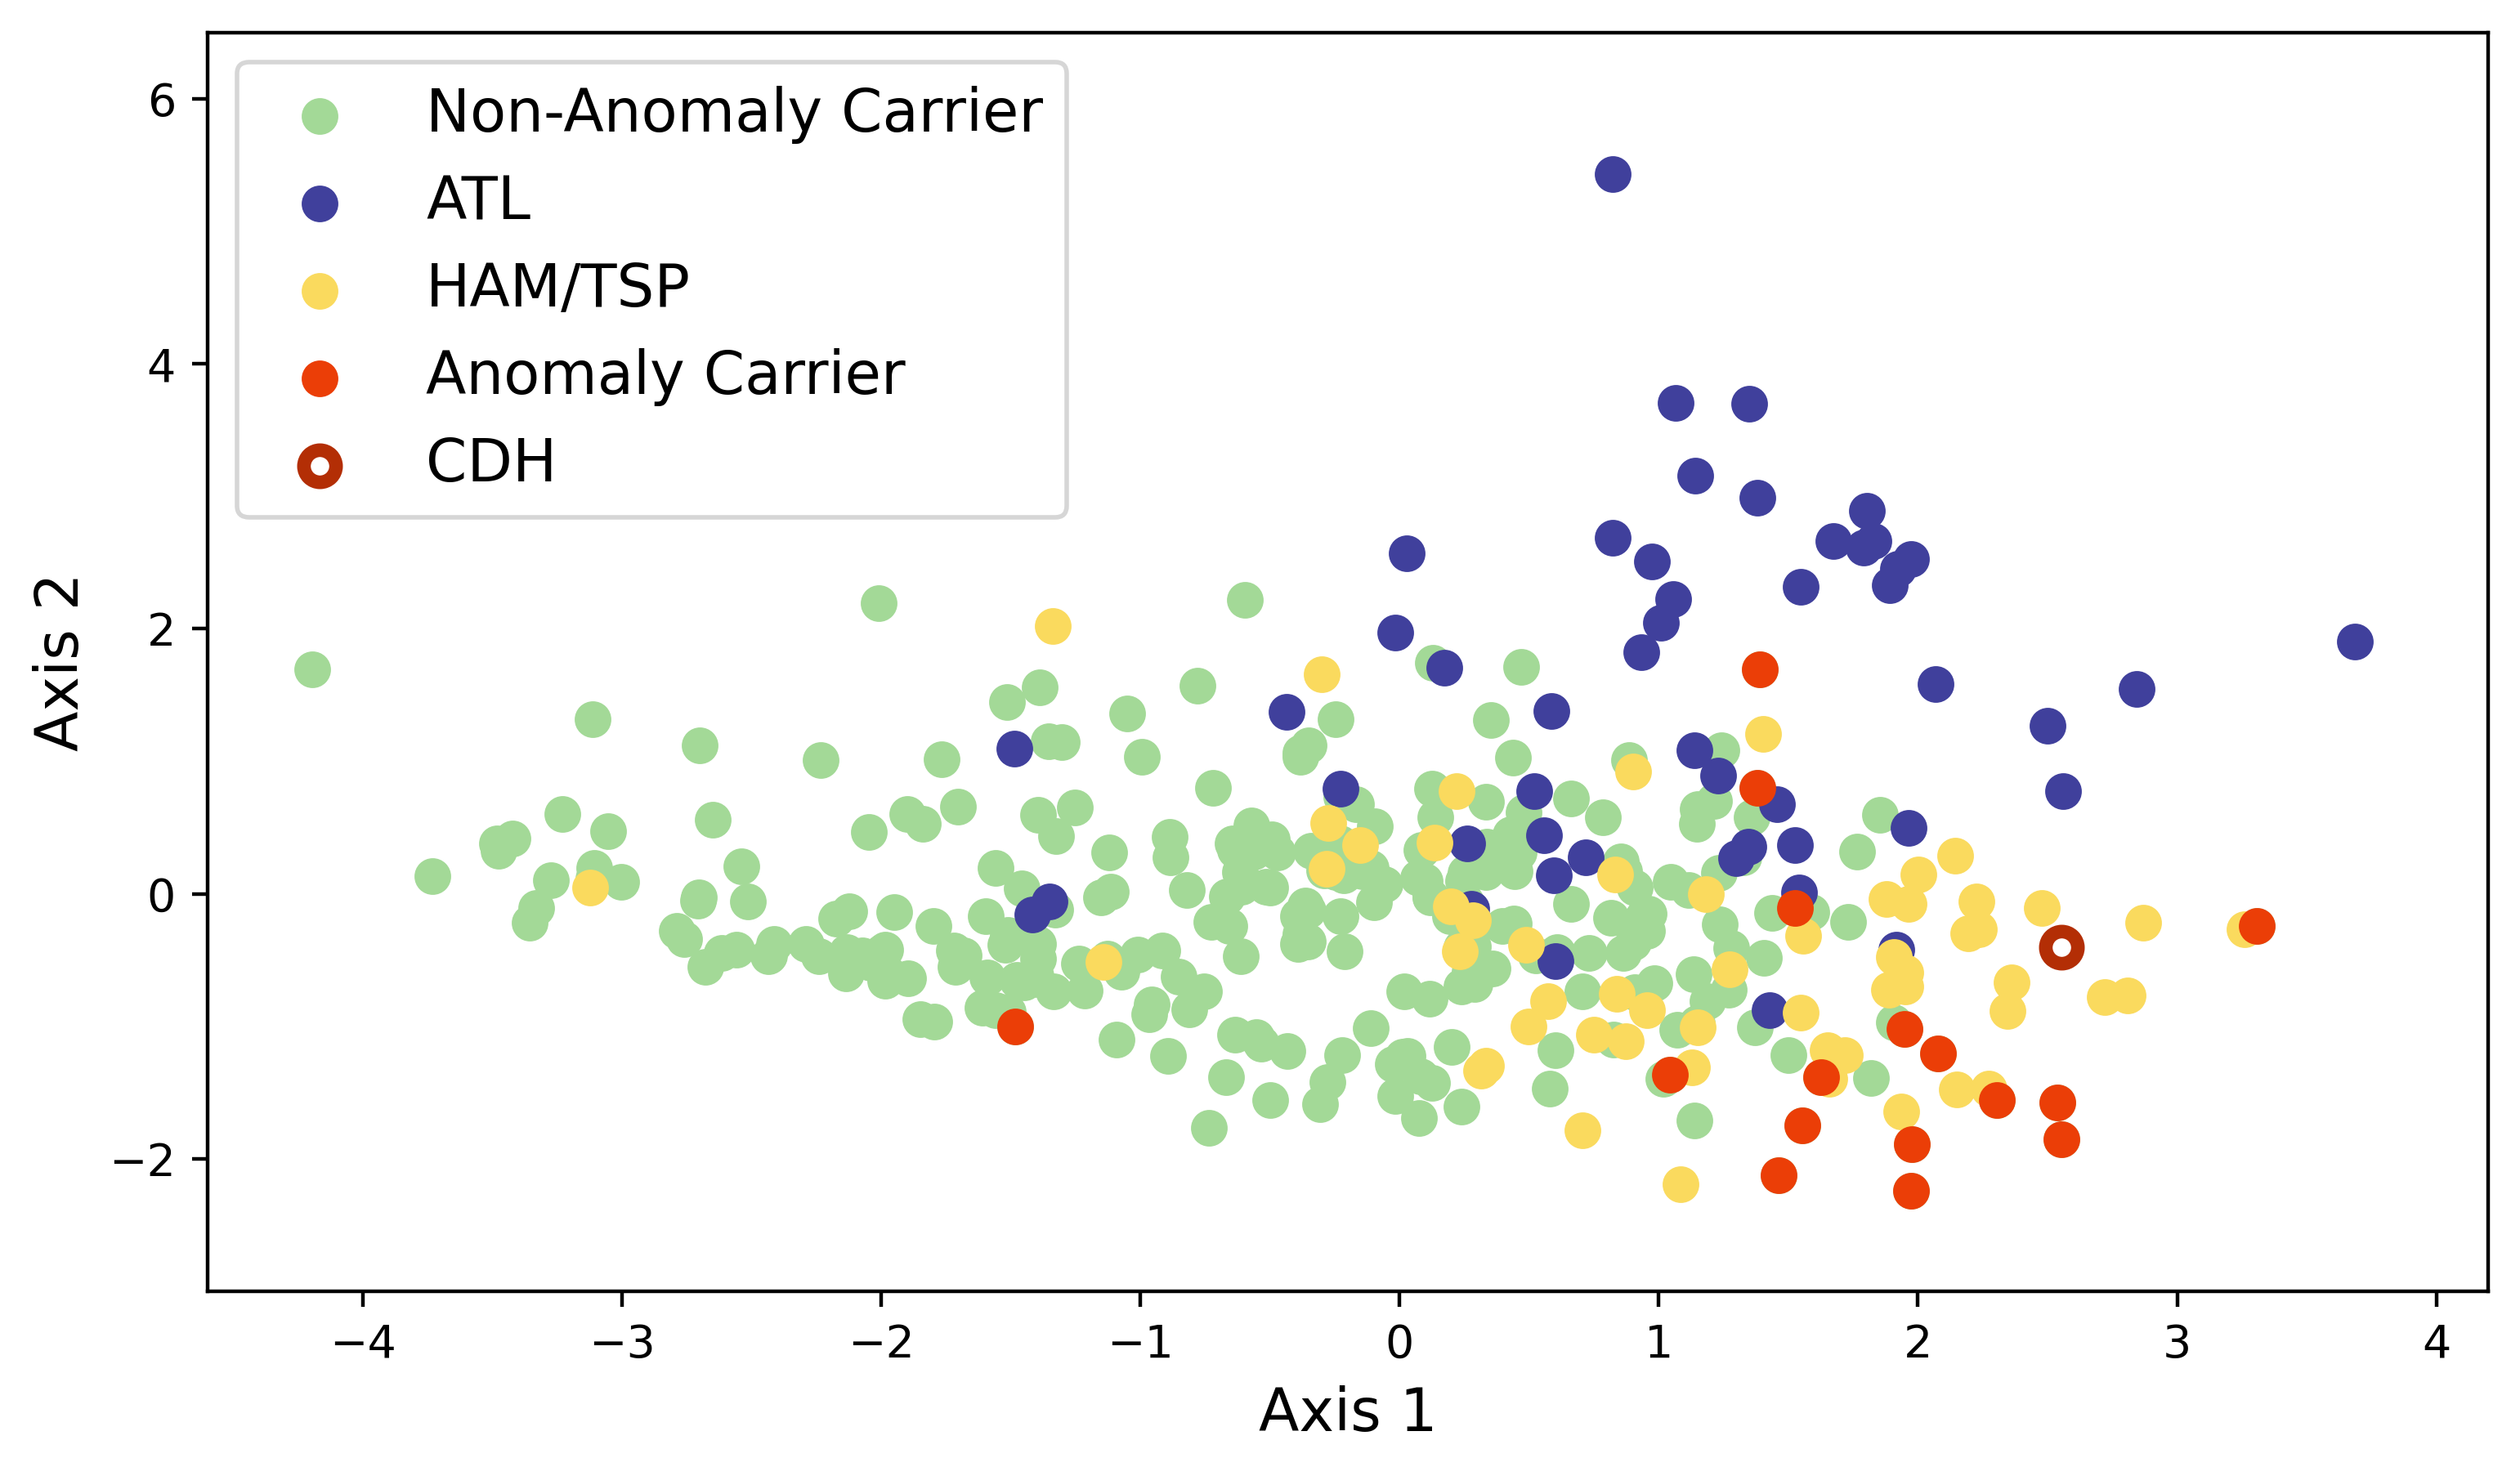

In [54]:
# color list and labels
color_list = {
    'Carrier': '#A3D997', 'ATL': '#40409C', 'HAM': '#fada5e', 
    'Anomaly Carrier': '#eb3e07', 'CDH': '#B32E05'
}
class_label = {'Carrier': 'Non-Anomaly Carrier', 'ATL': 'ATL', 'HAM': 'HAM/TSP'}

# plot results
fig, ax = plt.subplots(figsize=(9, 5), dpi=400)

for i_class in ['Carrier', 'ATL', 'HAM']:
    subset = df_pls[df_pls['type'] == i_class]
    ax.scatter(subset['axis01'], subset['axis02'], color=color_list[i_class], s=50, label=class_label[i_class])

# Plot anomaly carriers
anomalous_subset = df_pls[df_pls["indivID"].isin(anomalous_indices_carrier)]
ax.scatter(anomalous_subset['axis01'], anomalous_subset['axis02'], s=50, color=color_list["Anomaly Carrier"], label="Anomaly Carrier")

# highlight CDH
ax.scatter(CDH_df_pls["axis01"], CDH_df_pls["axis02"], s=50, fc="white", ec=color_list["CDH"], linewidth=3, label="CDH")

# final plot 
plt.legend(loc='upper left', fontsize=13)
plt.xlabel('Axis 1', fontsize=13)
plt.ylabel('Axis 2', fontsize=13)
plt.xlim(-4.6, 4.2)
plt.ylim(-3, 6.5)
plt.show()

# 4. Statistical Analysis

## 4.1. Pre-processing

In [55]:
stat_df = data.copy()

In [56]:
stat_df.drop('target', axis=1, inplace=True)

In [57]:
anomalous_indices_carrier = [
    'indiv0027', 'indiv0035', 'indiv0069', 'indiv0086', 'indiv0125',
    'indiv0131', 'indiv0133', 'indiv0169', 'indiv0189', 'indiv0217',
    'indiv0221', 'indiv0227', 'indiv0240', 'indiv0245', 'indiv0249',
    'indiv0254', 'indiv0265'
]

In [58]:
# add anomaly carriers to the type & update the dataframe
stat_df.loc[anomalous_indices_carrier, 'type'] = stat_df.loc[anomalous_indices_carrier, 'type'].replace('Carrier', 'Anomaly carrier')

In [59]:
stat_df["type"].value_counts()

type
Carrier            247
HAM                 56
ATL                 49
Anomaly carrier     17
Name: count, dtype: int64

## 4.2. Kruskal-Wallis test

In [60]:
import scipy.stats as stats
import scikit_posthocs as sp

In [61]:
random_seed = 42

group_names = ['Carrier', 'ATL', 'HAM', 'Anomaly carrier']

groups = [stat_df[stat_df['type'] == group_name] for group_name in group_names]

combined_data = pd.concat(groups)

# store test results
kruskal_results = {}
posthoc_p_values = {}

#features
numerical_features = ['PVL', 'Tax', 'Env', 'Gag p15', 'Gag p19', 'Gag p24']

In [62]:
# KW analysis
for feature in numerical_features:
    kruskal_statistic, p_value = stats.kruskal(
        *[combined_data[combined_data['type'] == type][feature] for type in group_names]
    )
    kruskal_results[feature] = {'Kruskal Statistic': kruskal_statistic, 'p-value': p_value}

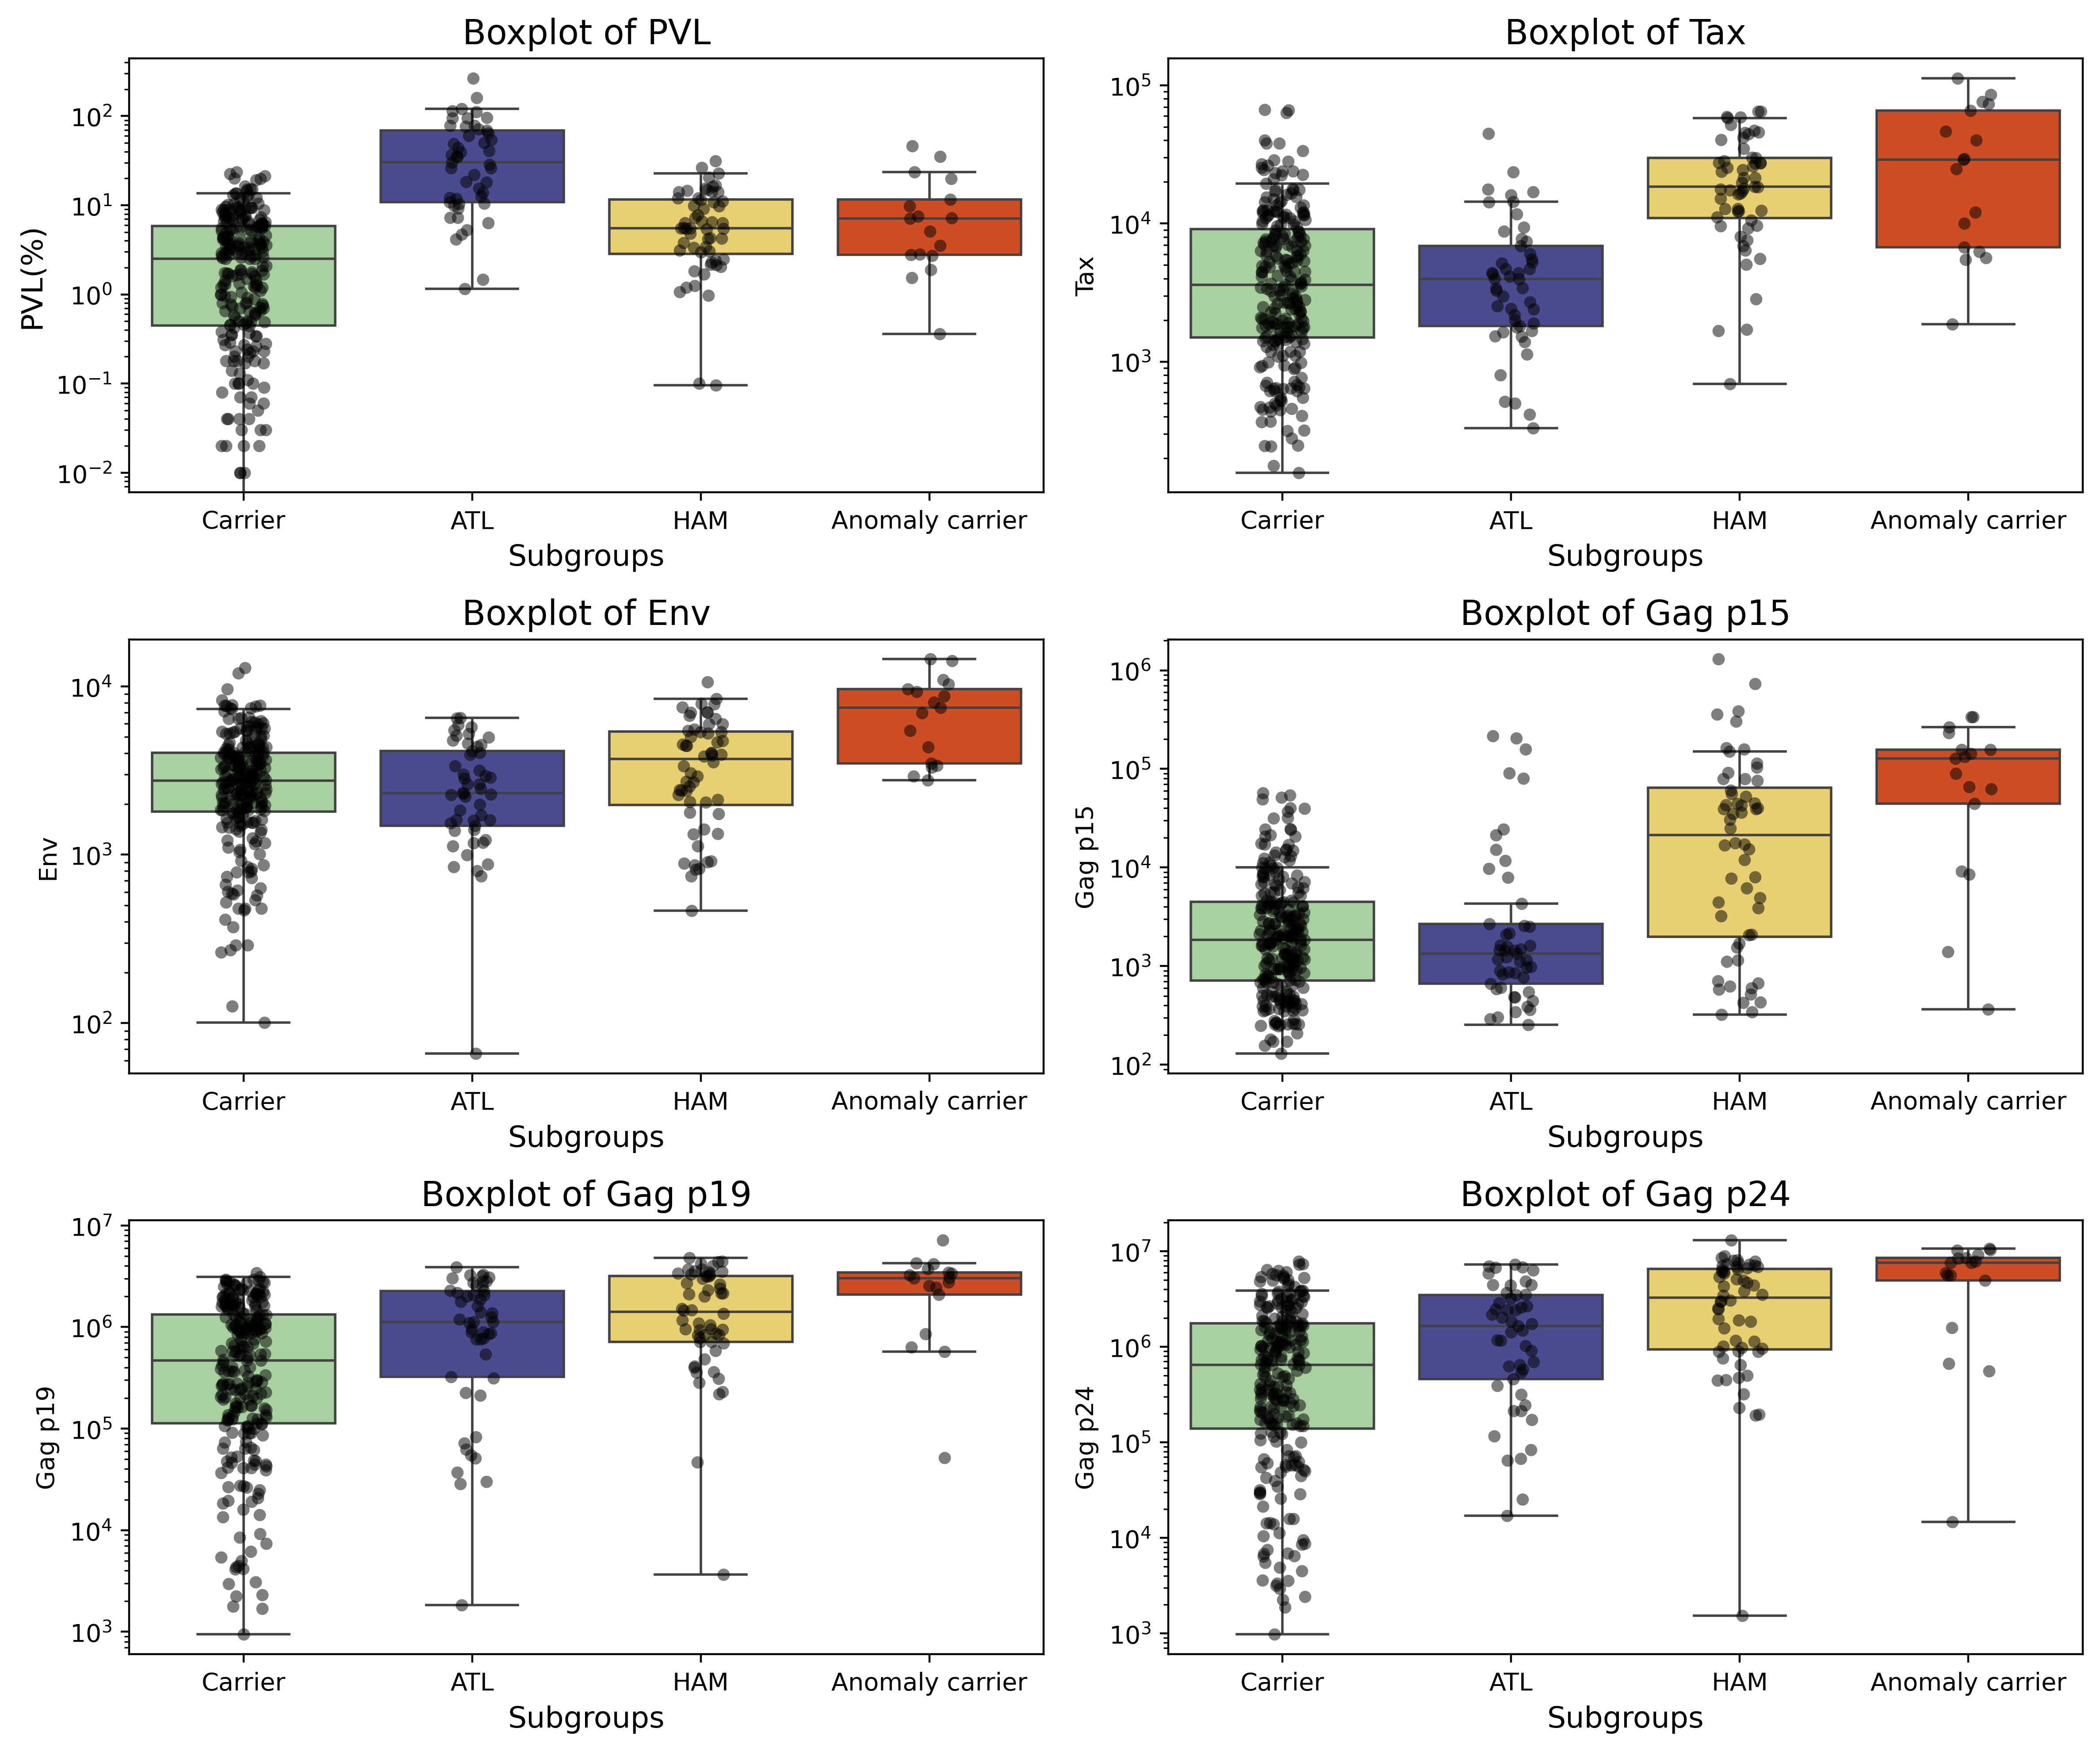

In [63]:
# Visualization of KW

plt.figure(figsize=(12, 10), dpi=400)
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x='type', y=feature, data=combined_data, palette=["#A3D997", "#40409C", "#FADA5E", "#EB3E07"], showfliers=False)
    sns.stripplot(x='type', y=feature, data=combined_data, color='black', alpha=0.5, jitter=True)
    
    # Set title with larger font size
    plt.title(f'Boxplot of {feature}', fontsize=14)
    
    # Set y-axis label with larger font size
    if i == 0:
        plt.ylabel('PVL(%)', fontsize=12)
    
    # Set x-axis label with larger font size
    plt.xlabel('Subgroups', fontsize=12)
    
    plt.yscale('log')
    
plt.tight_layout()
plt.show()

In [64]:
# Print Kruskal-Wallis test results
for feature, result in kruskal_results.items():
    print(f'Kruskal-Wallis Test for {feature}:')
    print(f'Kruskal Statistic: {result["Kruskal Statistic"]:.4f}')
    print(f'p-value: {result["p-value"]:.4f}')
    print('\n')

Kruskal-Wallis Test for PVL:
Kruskal Statistic: 111.6197
p-value: 0.0000


Kruskal-Wallis Test for Tax:
Kruskal Statistic: 85.7361
p-value: 0.0000


Kruskal-Wallis Test for Env:
Kruskal Statistic: 28.1111
p-value: 0.0000


Kruskal-Wallis Test for Gag p15:
Kruskal Statistic: 59.4299
p-value: 0.0000


Kruskal-Wallis Test for Gag p19:
Kruskal Statistic: 55.4303
p-value: 0.0000


Kruskal-Wallis Test for Gag p24:
Kruskal Statistic: 66.4650
p-value: 0.0000




In [65]:
# dunn's post hoc test
for feature in numerical_features:
    posthoc_p_value = sp.posthoc_dunn(
        combined_data, val_col=feature, group_col='type', p_adjust='bonferroni'
    )
    posthoc_p_values[feature] = posthoc_p_value

# Print results
for feature, p_values in posthoc_p_values.items():
    print(f"Dunn's Test for {feature}:")
    for i, group1 in enumerate(group_names):
        for j, group2 in enumerate(group_names):
            if i < j:
                p_value = p_values.loc[group1, group2]
                if p_value < 0.05:
                    print(f"    {group1} vs. {group2}: Significant (p = {p_value:.4f})")
                else:
                    print(f"    {group1} vs. {group2}: Not Significant (p = {p_value:.4f})")
    print('\n')

Dunn's Test for PVL:
    Carrier vs. ATL: Significant (p = 0.0000)
    Carrier vs. HAM: Significant (p = 0.0000)
    Carrier vs. Anomaly carrier: Significant (p = 0.0197)
    ATL vs. HAM: Significant (p = 0.0000)
    ATL vs. Anomaly carrier: Significant (p = 0.0190)
    HAM vs. Anomaly carrier: Not Significant (p = 1.0000)


Dunn's Test for Tax:
    Carrier vs. ATL: Not Significant (p = 1.0000)
    Carrier vs. HAM: Significant (p = 0.0000)
    Carrier vs. Anomaly carrier: Significant (p = 0.0000)
    ATL vs. HAM: Significant (p = 0.0000)
    ATL vs. Anomaly carrier: Significant (p = 0.0001)
    HAM vs. Anomaly carrier: Not Significant (p = 1.0000)


Dunn's Test for Env:
    Carrier vs. ATL: Not Significant (p = 1.0000)
    Carrier vs. HAM: Not Significant (p = 0.3102)
    Carrier vs. Anomaly carrier: Significant (p = 0.0000)
    ATL vs. HAM: Not Significant (p = 0.1995)
    ATL vs. Anomaly carrier: Significant (p = 0.0000)
    HAM vs. Anomaly carrier: Significant (p = 0.0048)


Dunn's 

# 5. Appendix

In [66]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr

In [67]:
data = pd.read_csv('all_data_copy.csv', index_col=0)
data = data.replace('Carrier_to_ATL','ATL')
data = data.replace('Carrier_to_HAM','Carrier')

## 5.1. Correlation between feature values

In [68]:
df_corr = data.copy()
df_corr.drop('type', axis=1, inplace=True)

corr = df_corr.corr(method='spearman')

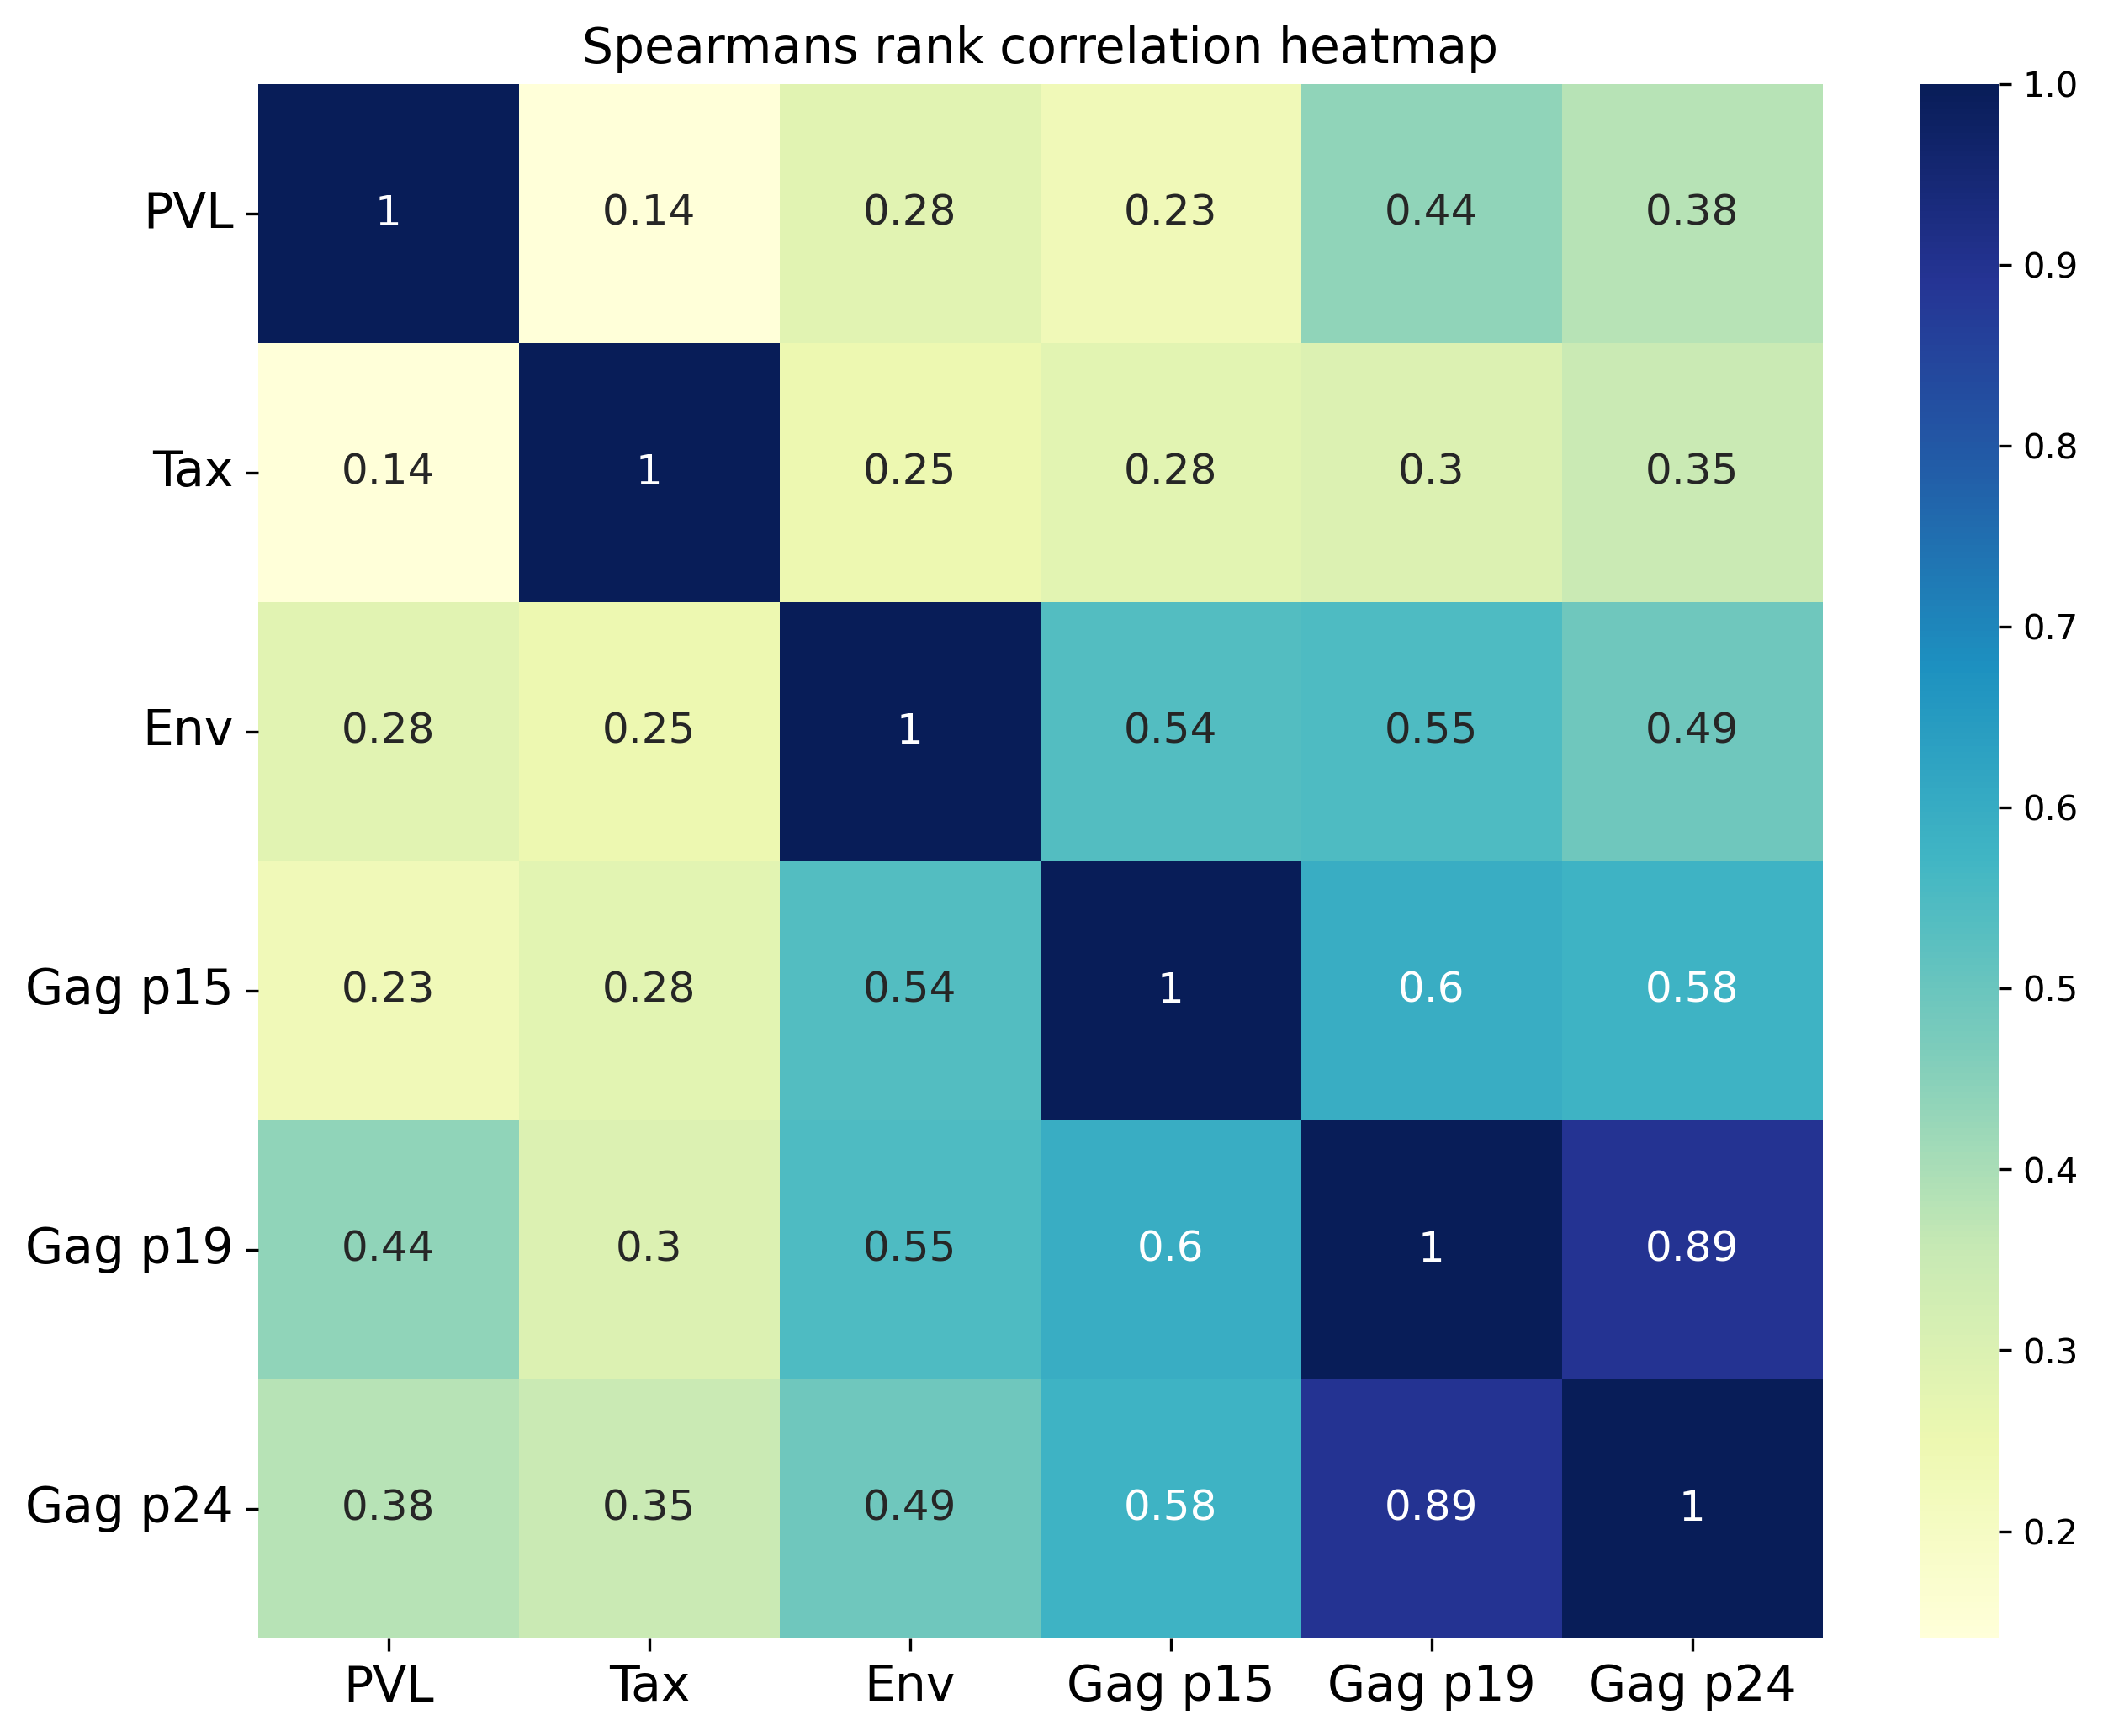

In [69]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
heatmap = sns.heatmap(corr, cmap='YlGnBu', annot=True, annot_kws={'size': 12}, ax=ax)
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=14)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=14, rotation=0)
plt.title('Spearmans rank correlation heatmap', fontsize=14)
plt.show()

In [70]:
rho_1, p_1 = spearmanr(df_corr['Gag p24'], df_corr['Gag p19'])
rho_2, p_2 = spearmanr(df_corr['Gag p15'], df_corr['Gag p19'])
rho_3, p_3 = spearmanr(df_corr['Gag p15'], df_corr['Gag p24'])
rho_4, p_4 = spearmanr(df_corr['Gag p19'], df_corr['Env'])
rho_5, p_5 = spearmanr(df_corr['Gag p15'], df_corr['Env'])

In [71]:
print(rho_1), print(rho_2), print(rho_3), print(rho_4), print(rho_5)

0.8945945945945947
0.5951554824867404
0.5802632652152545
0.5500548912046288
0.5393983210080353


(None, None, None, None, None)

In [72]:
print(p_1), print(p_2), print(p_3), print(p_4), print(p_5)

1.93629122596502e-130
9.86986348213727e-37
1.3693876740743134e-34
1.4444299619691229e-30
3.0459400422368776e-29


(None, None, None, None, None)

## 5.2. Contour plot of Anomaly Score distribution among Carriers

In [73]:
from scipy.interpolate import griddata

# Copy X_carrier and add anomaly scores
carrier_log = X_carrier.copy()
carrier_log['Anomaly_Score'] = anomaly_scores_carrier

# Create DataFrame with PLS scores
df_pls = pd.DataFrame(pls_score, columns=['axis01', 'axis02'], index=data.index)
df_pls['type'] = data['type']

# Filter only Carriers
pls_carriers = df_pls[df_pls['type'] == 'Carrier'].copy()
pls_carriers.reset_index(inplace=False)
pls_carriers.drop(columns=['type'], inplace=True)

# Merge Anomaly Scores to pls score
pls_carriers['Anomaly_Score'] = carrier_log.iloc[:, -1] 

# Extract feature values for contour plot
feature_x = pls_carriers['axis01']
feature_y = pls_carriers['axis02']
Z = pls_carriers['Anomaly_Score']

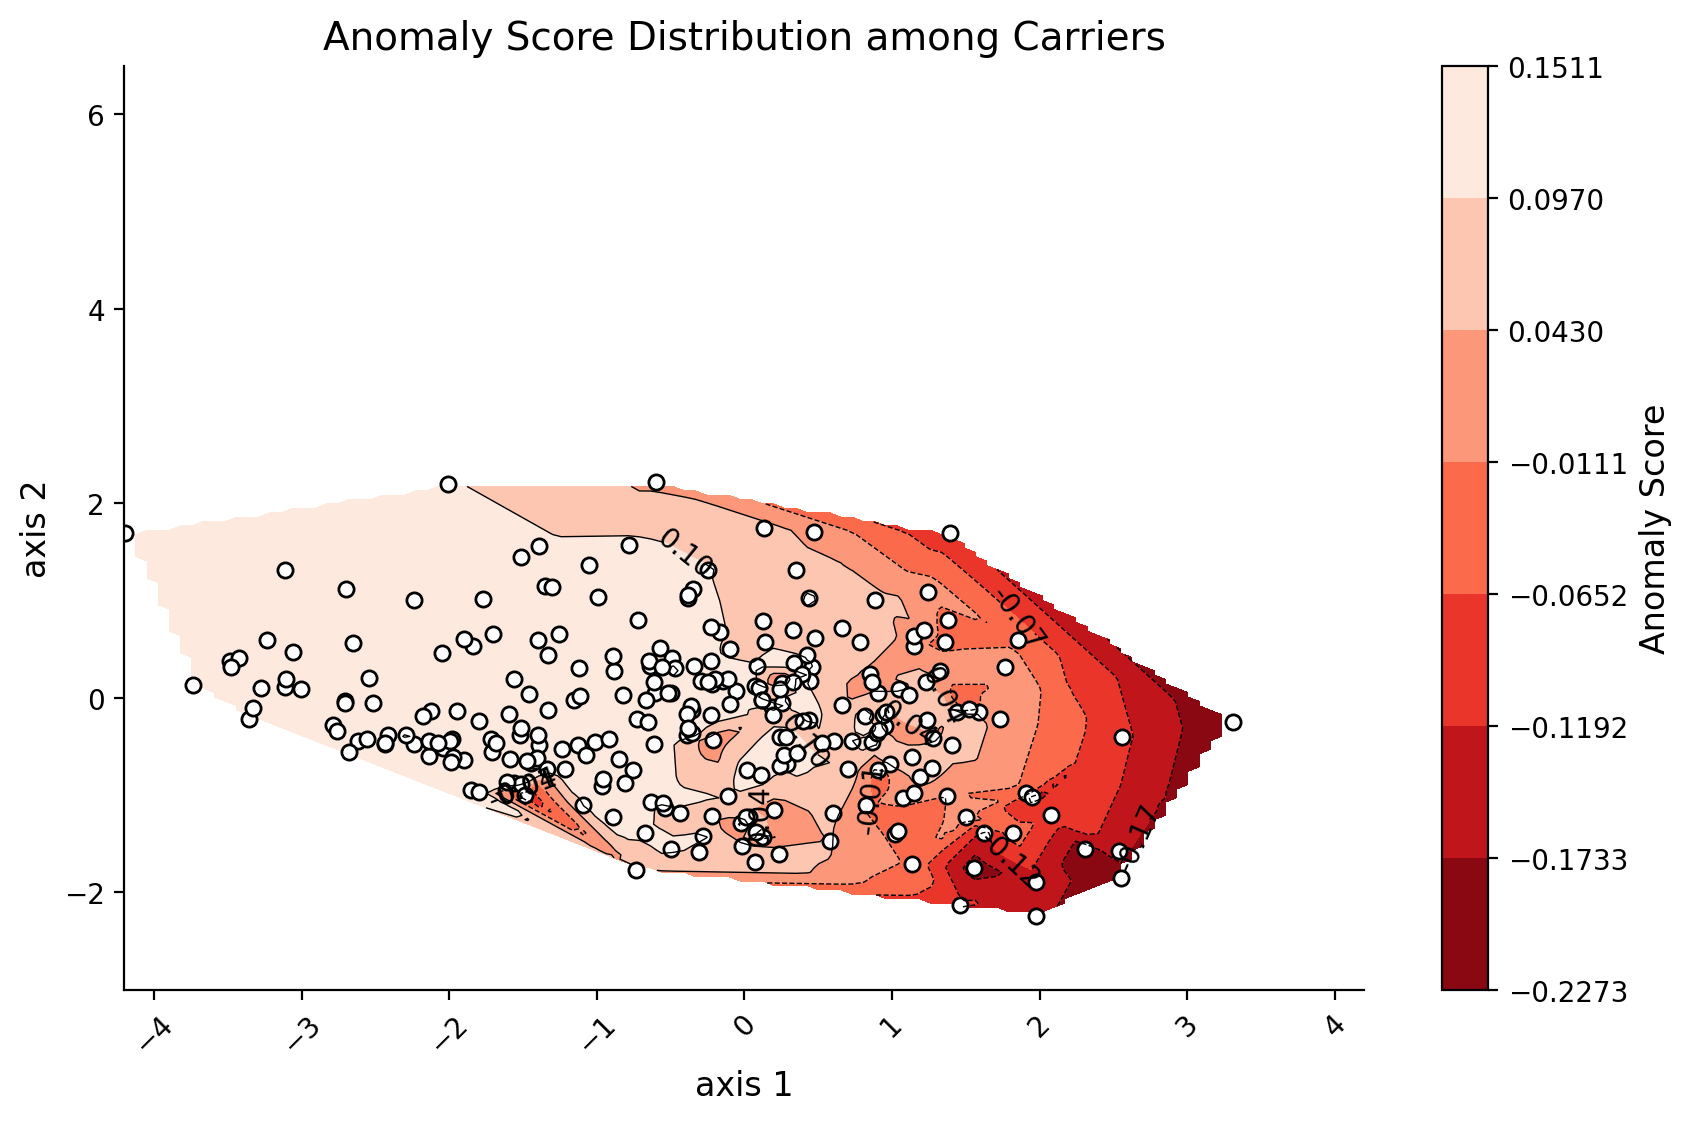

In [74]:
len(pls_carriers), len(carrier_log)

# Create mesh grid
x_min, x_max = feature_x.min(), feature_x.max()
y_min, y_max = feature_y.min(), feature_y.max()
X, Y = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolate Z values
Z_interp = griddata((feature_x, feature_y), Z, (X, Y), method='linear')

# Plotting
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

# Define a range of levels within threshold range
levels = np.linspace(Z.min(), Z.max(), 8)  

# Plot the contour 
contour_filled = ax.contourf(X, Y, Z_interp, levels=levels, cmap=plt.cm.Reds_r)
# cbar = plt.colorbar(contour_filled)
# cbar.ax.tick_params(labelsize=10)  
# cbar.set_label('Anomaly Score', fontsize=12)


for i, j in zip(feature_x, feature_y):
     ax.scatter(i, j, s = 30, color = "black", fc = "white")

# Add contour lines
contour_lines = ax.contour(X, Y, Z_interp, levels=levels, colors='black', linewidths=0.5)
ax.clabel(contour_lines, inline=True, fontsize=10, fmt='%1.2f')

ax.set_title('Anomaly Score Distribution among Carriers', fontsize=14)
ax.set_xlabel('axis 1', fontsize=12)
ax.set_ylabel('axis 2', fontsize=12)

cbar = plt.colorbar(contour_filled)
cbar.ax.tick_params(labelsize=10)  
cbar.set_label('Anomaly Score', fontsize=12)

ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-3, 6.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

## 5.3. Anomaly score vs Feature value of Anomaly carriers

In [75]:
index_list = actual_anomalies_carrier.index.tolist()

anomalous_data_carrier = actual_anomalies_carrier.copy()

# get the index of the rows of anomalous_data
anomalous_indices_carrier = anomalous_data_carrier.index
#actual_anomalies_carrier.to_csv('actual_anomalies_carrier.csv', index=True)

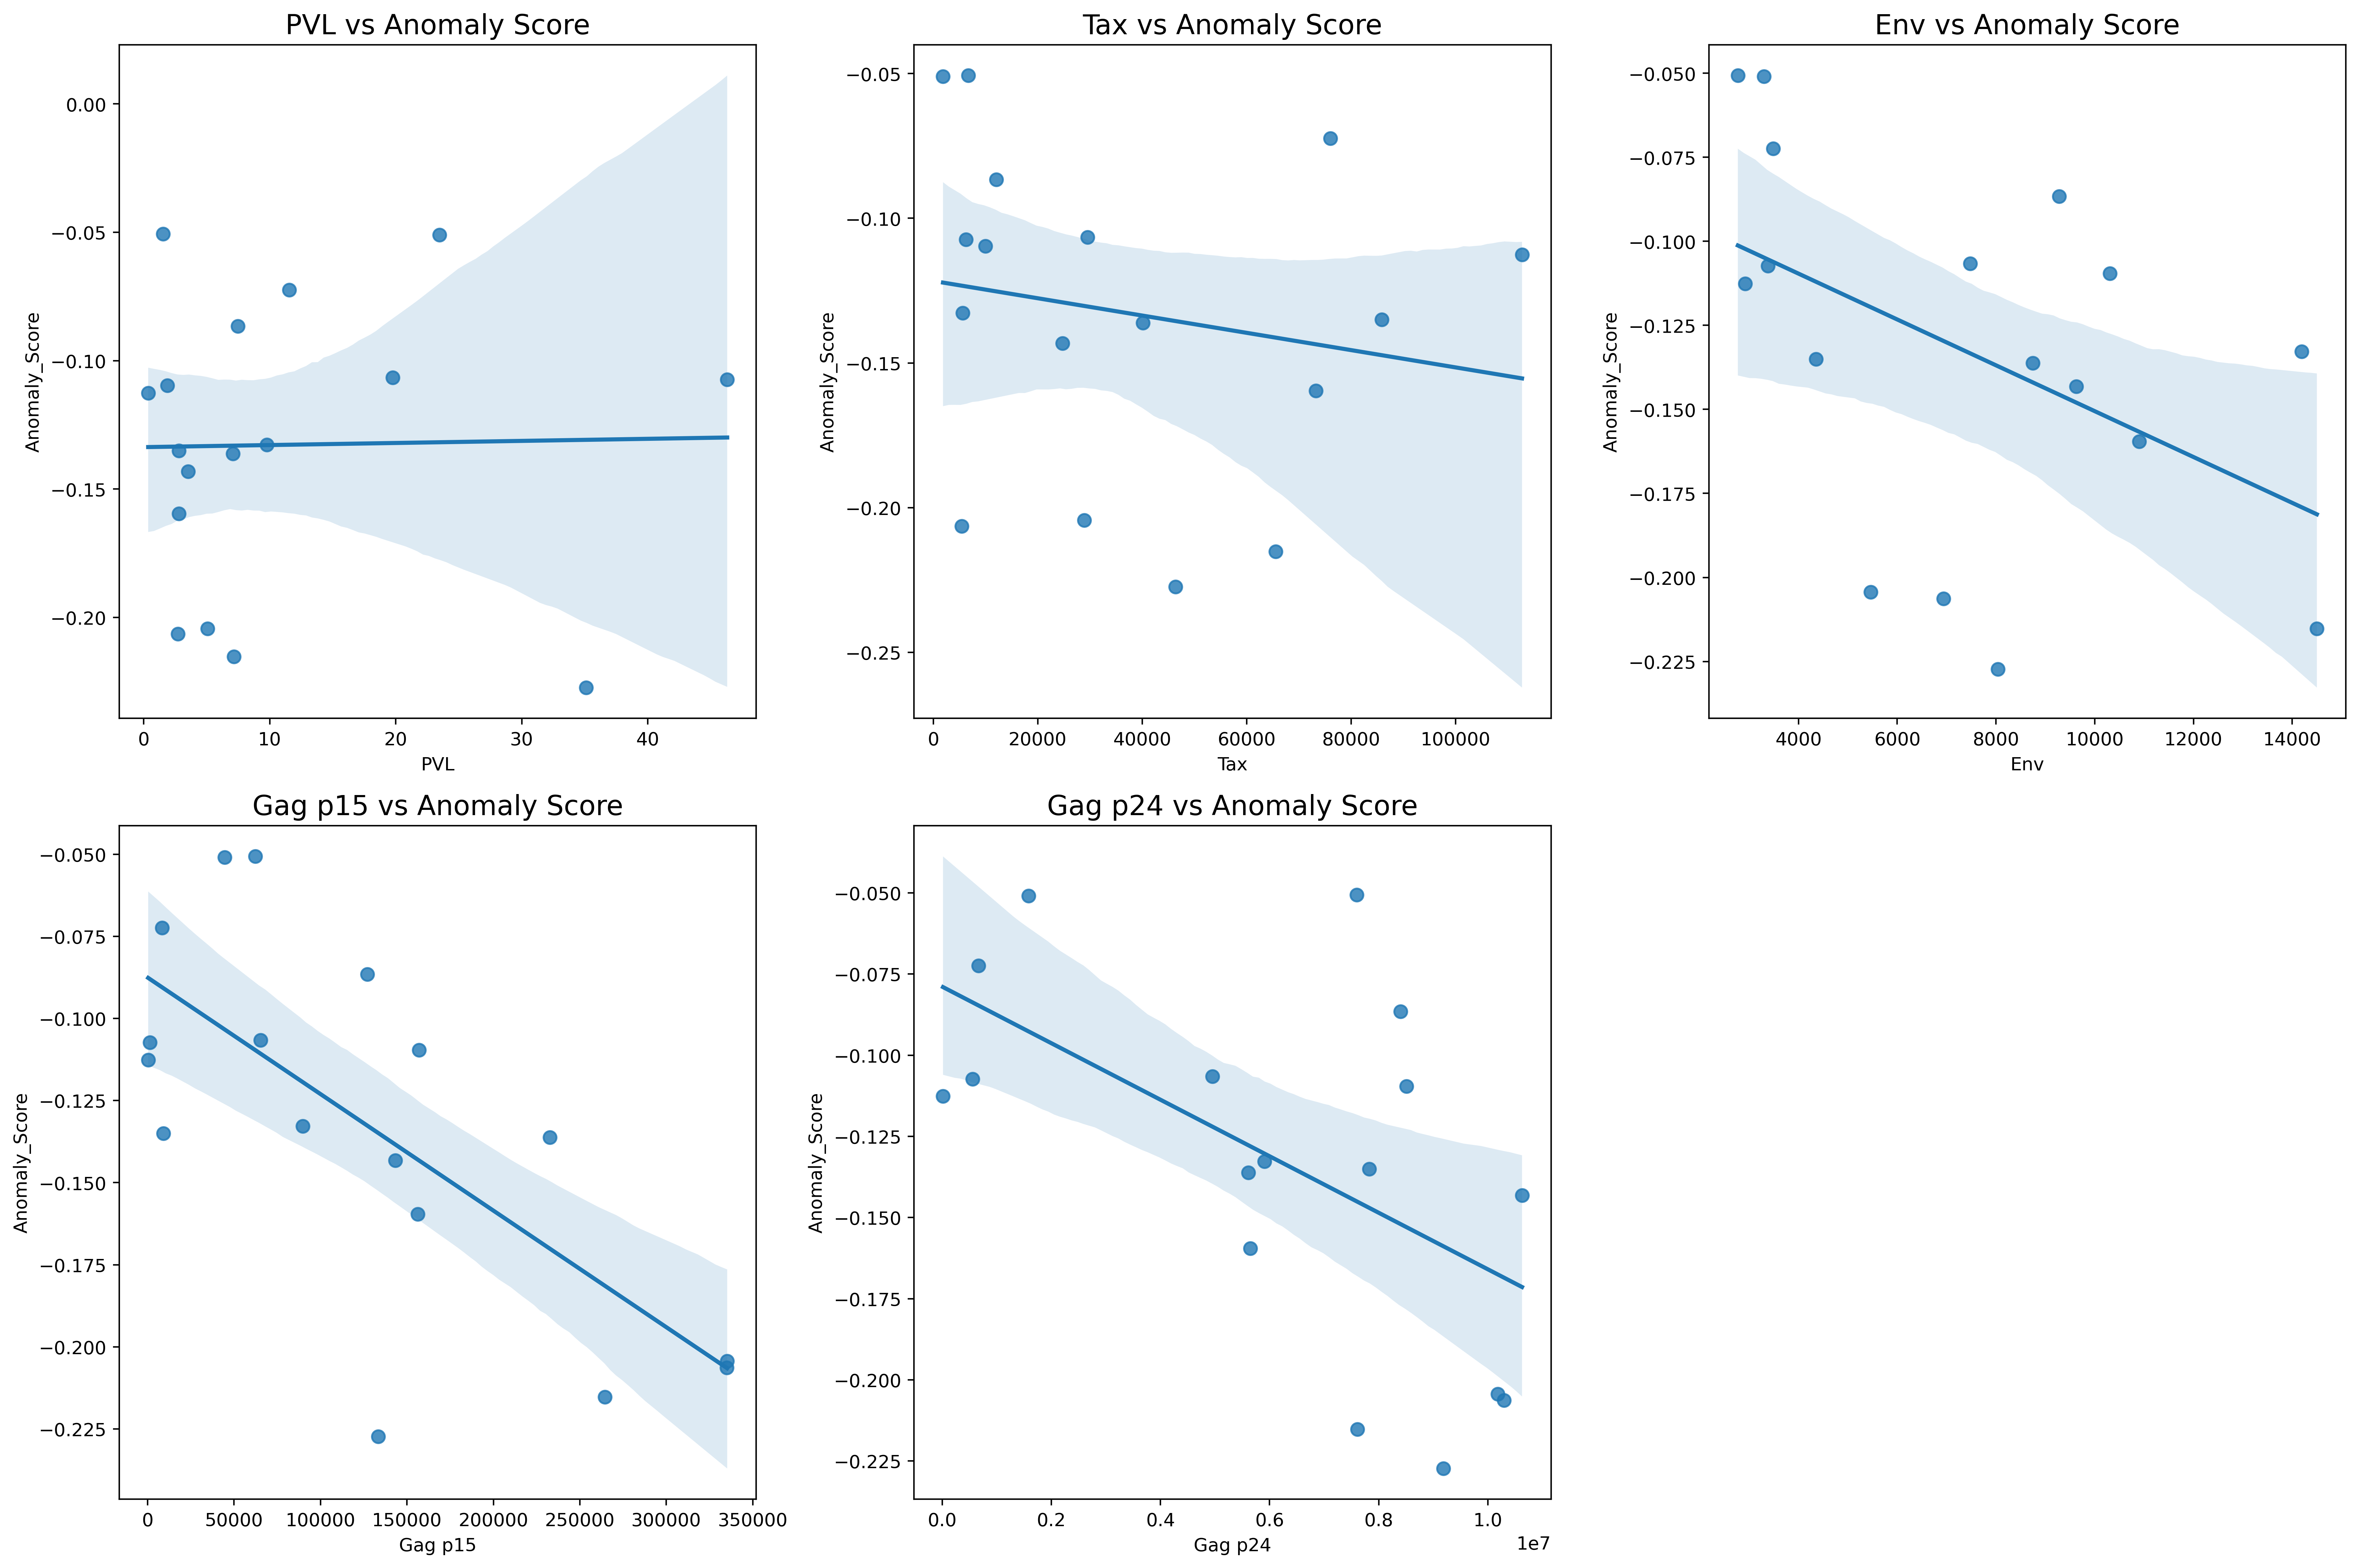

In [76]:
# Set up figures with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12), dpi= 400)

# Plotting each feature against anomaly score with 95% CI
sns.regplot(x='PVL', y='Anomaly_Score', data=actual_anomalies_carrier, ax=axes[0, 0], scatter_kws={'s': 50}, ci=95)
axes[0, 0].set_title('PVL vs Anomaly Score', fontsize=15)

sns.regplot(x='Tax', y='Anomaly_Score', data=actual_anomalies_carrier, ax=axes[0, 1], scatter_kws={'s': 50}, ci=95)
axes[0, 1].set_title('Tax vs Anomaly Score', fontsize=15)

sns.regplot(x='Env', y='Anomaly_Score', data=actual_anomalies_carrier, ax=axes[0, 2], scatter_kws={'s': 50}, ci=95)
axes[0, 2].set_title('Env vs Anomaly Score', fontsize=15)

sns.regplot(x='Gag p15', y='Anomaly_Score', data=actual_anomalies_carrier, ax=axes[1, 0], scatter_kws={'s': 50}, ci=95)
axes[1, 0].set_title('Gag p15 vs Anomaly Score', fontsize=15)

sns.regplot(x='Gag p24', y='Anomaly_Score', data=actual_anomalies_carrier, ax=axes[1, 1], scatter_kws={'s': 50}, ci=95)
axes[1, 1].set_title('Gag p24 vs Anomaly Score', fontsize=15)

axes[1, 2].set_visible(False)

fig.tight_layout() 
plt.show()

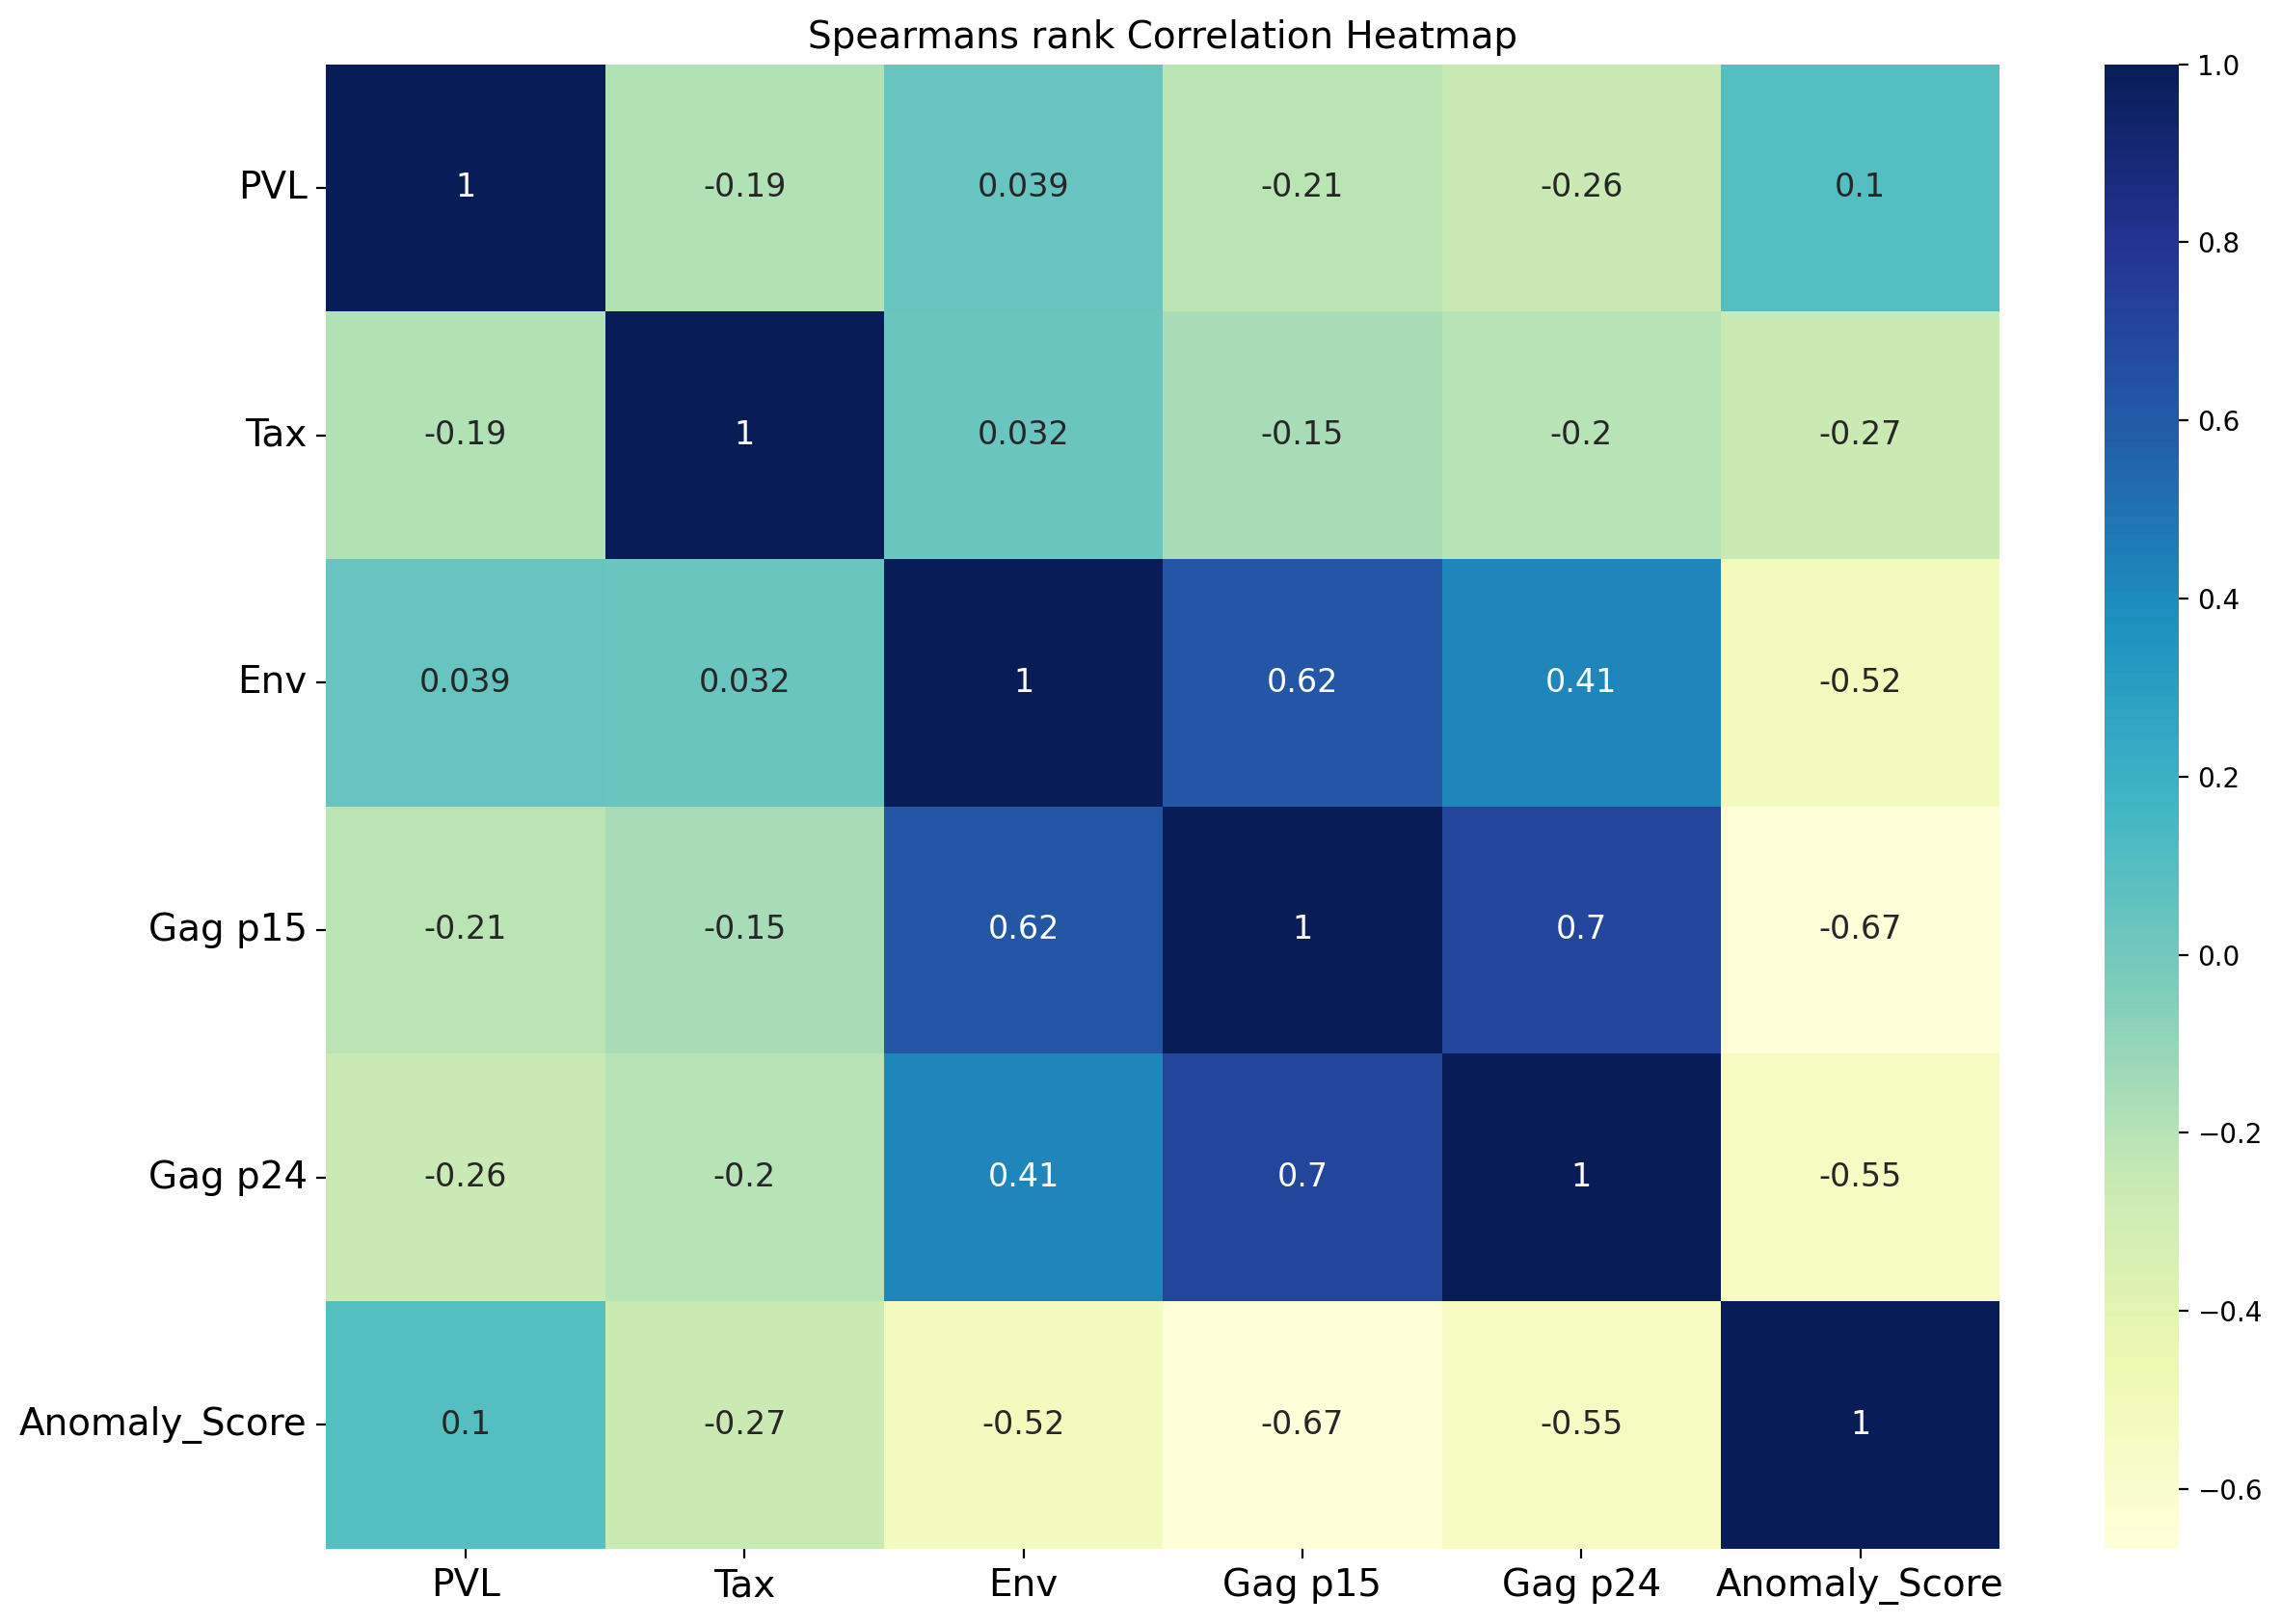

In [77]:
#correlation analysis
ascor_spearman = actual_anomalies_carrier.corr(method='spearman')
fig, ax = plt.subplots(figsize=(14, 10), dpi=200)
heatmap = sns.heatmap(ascor_spearman, cmap='YlGnBu', annot=True, annot_kws={'size': 12}, ax=ax)
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=14)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=14, rotation=0)
plt.title('Spearmans rank Correlation Heatmap', fontsize=14)
plt.show()

In [78]:
rho_p15, p_p15 = spearmanr(actual_anomalies_carrier['Gag p15'], actual_anomalies_carrier['Anomaly_Score'])
rho_p24, p_p24 = spearmanr(actual_anomalies_carrier['Gag p24'], actual_anomalies_carrier['Anomaly_Score'])
rho_env, p_env = spearmanr(actual_anomalies_carrier['Env'], actual_anomalies_carrier['Anomaly_Score'])
rho_tax, p_tax = spearmanr(actual_anomalies_carrier['Tax'], actual_anomalies_carrier['Anomaly_Score'])
rho_pvl, p_pvl = spearmanr(actual_anomalies_carrier['PVL'], actual_anomalies_carrier['Anomaly_Score'])

In [79]:
print(rho_p15), print(rho_p24), print(rho_env), print(rho_tax), print(rho_pvl)

-0.6666666666666667
-0.5490196078431373
-0.5196078431372549
-0.26715686274509803
0.10049019607843139


(None, None, None, None, None)

In [80]:
print(p_p15),  print(p_p24), print(p_env), print(p_tax), print(p_pvl)

0.0034699602434103967
0.022461151768182565
0.03253716699175945
0.29991791209590246
0.7011667687510688


(None, None, None, None, None)

## 5.4. Correlation between Feature values & Predicted probability of HAM among Anomaly carriers

In [81]:
test_anomaly_copy= test_anomaly_carrier.copy()

In [82]:
test_anomaly_copy.drop(["pred_label", "prob_class_0", "prob_class_1"], axis=1, inplace=True)

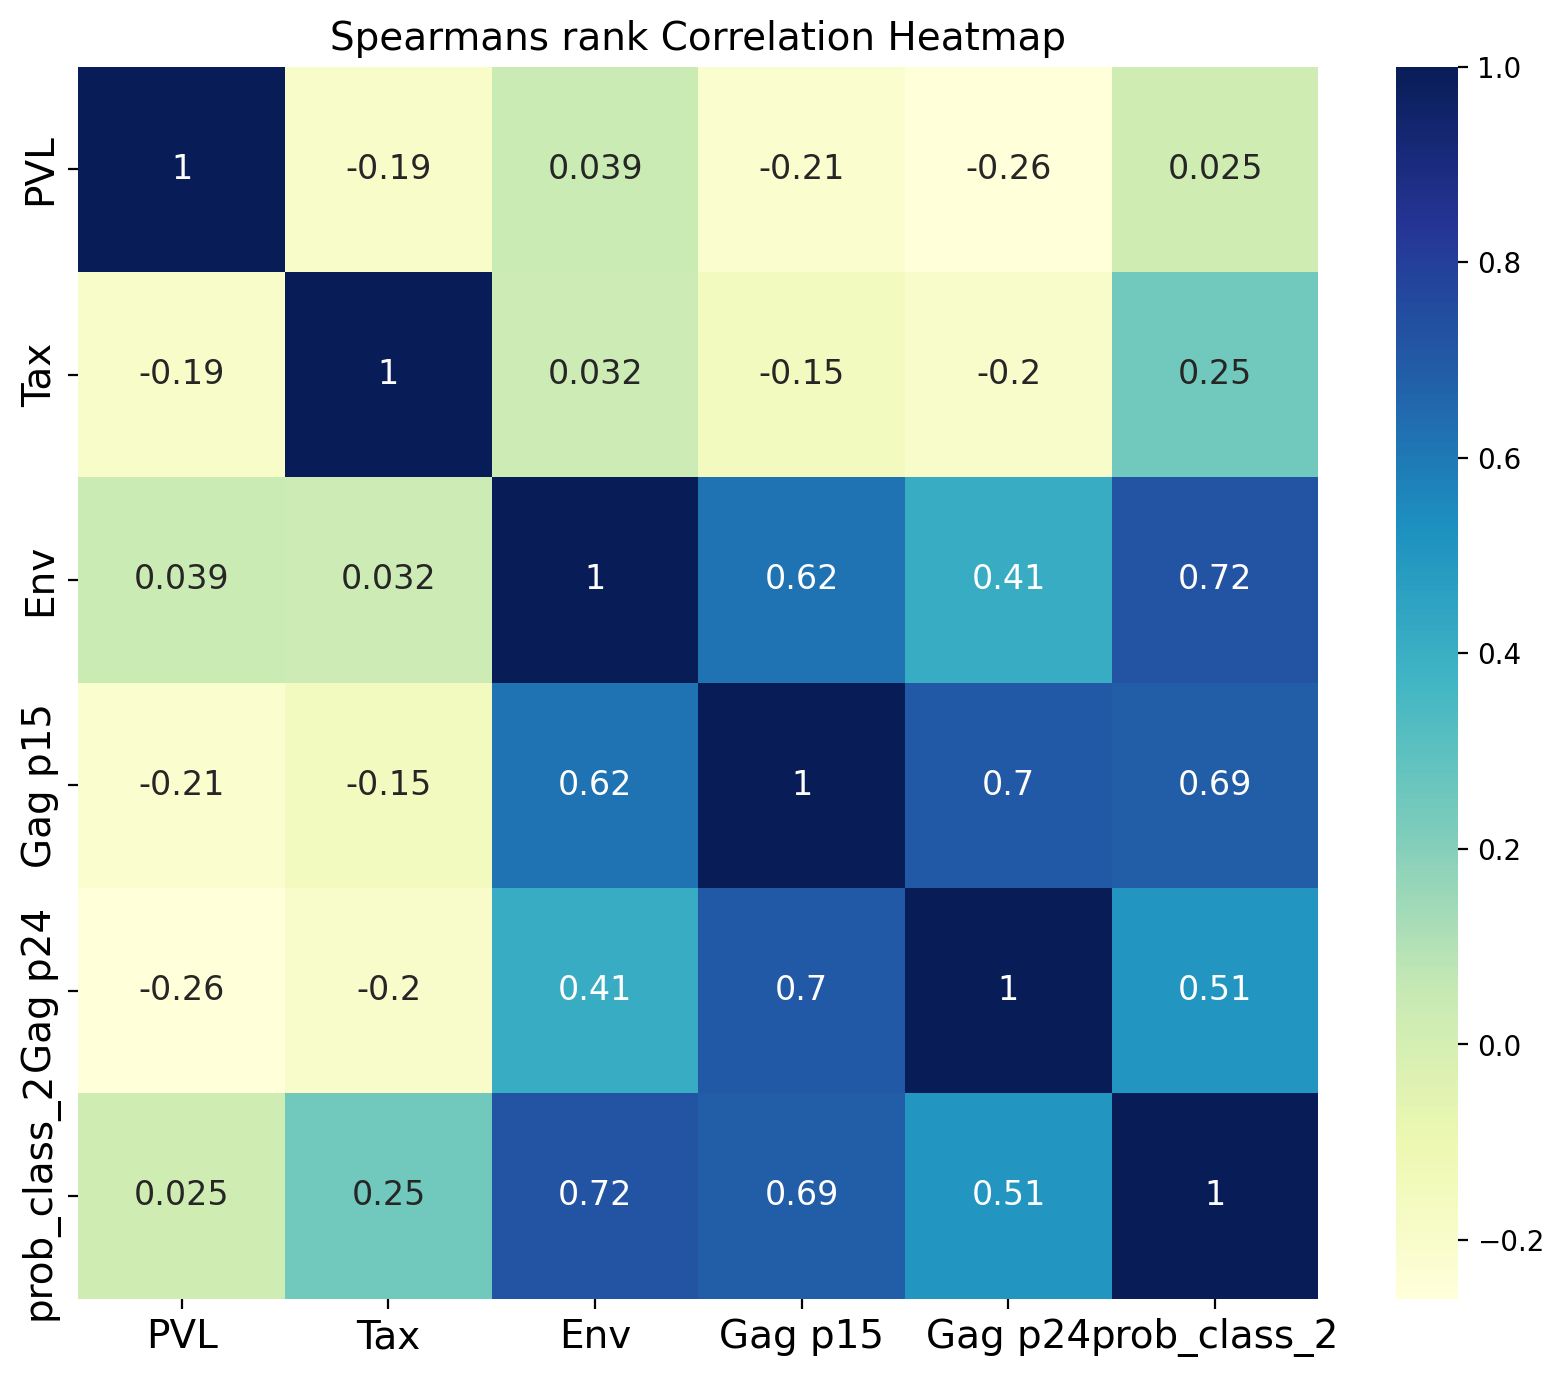

In [83]:
acppr = test_anomaly_copy.corr(method='spearman')
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)
heatmap = sns.heatmap(acppr, cmap='YlGnBu', annot=True, annot_kws={'size': 12}, ax=ax)
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=14)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=14)
plt.title('Spearmans rank Correlation Heatmap', fontsize=14)
plt.show()

In [84]:
rho_p24, p_value_p24 = spearmanr(test_anomaly_copy['Gag p24'], test_anomaly_copy['prob_class_2'])
rho_tax, p_value_tax = spearmanr(test_anomaly_copy['Tax'], test_anomaly_copy['prob_class_2'])
rho_p15, p_value_p15 = spearmanr(test_anomaly_copy['Gag p15'], test_anomaly_copy['prob_class_2'])
rho_env, p_value_env = spearmanr(test_anomaly_copy['Env'], test_anomaly_copy['prob_class_2'])
rho_pvl, p_value_pvl = spearmanr(test_anomaly_copy['PVL'], test_anomaly_copy['prob_class_2'])

In [85]:
print(rho_p24), print(rho_tax), print(rho_p15), print(rho_env), print(rho_pvl)

0.5067488477165407
0.2515339316752805
0.6871170816495467
0.7239269253093438
0.024539895773198095


(None, None, None, None, None)

In [86]:
print(p_value_p24), print(p_value_tax), print(p_value_p15), print(p_value_env),print(p_value_pvl)

0.03789889365328781
0.3301137004965352
0.0023085010905025375
0.0010176541024397457
0.9255166791844643


(None, None, None, None, None)

## 6. Required packages

In [87]:
# package versions
import pkg_resources

dependencies = ['scikit-learn', 'scikit-posthocs', 'numpy', 'pandas', 'matplotlib', 'seaborn', 'scipy', 'statsmodels', 'xgboost']  
for package in dependencies:
    try:
        version = pkg_resources.get_distribution(package).version
        print(f"{package}=={version}")
    except:
        print(f"{package} not installed")

scikit-learn==1.5.2
scikit-posthocs==0.11.0
numpy==1.24.4
pandas==2.2.3
matplotlib==3.9.2
seaborn==0.13.2
scipy==1.13.1
statsmodels==0.14.4
xgboost==2.1.3


In [88]:
import notebook
print(notebook.__version__)

7.2.2


In [89]:
!jupyter --version

Selected Jupyter core packages...
IPython          : 8.12.3
ipykernel        : 6.29.5
ipywidgets       : 8.1.5
jupyter_client   : 8.6.3
jupyter_core     : 5.7.2
jupyter_server   : 2.14.2
jupyterlab       : 4.2.6
nbclient         : 0.10.1
nbconvert        : 7.16.4
nbformat         : 5.10.4
notebook         : 7.2.2
qtconsole        : 5.6.1
traitlets        : 5.14.3
